# Materials Price Matching

This notebook prepares the pricing bridge between the clustered materials data and the World Bank commodity price data. The goal is not to force a price onto every scientific material formula, but to create transparent price proxies with match types and confidence labels so later cost analysis only uses reasonable matches.

In [1]:
# Import the libraries used in this notebook section.
from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
# Set up project paths so files can be read and outputs can be organised consistently.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_dir = project_root / "data" / "processed"
# Group similar records and evaluate the quality of the cluster structure.
cluster_results_dir = project_root / "results" / "materials_clustering"
results_dir = project_root / "results" / "materials_pricing"
supporting_results_dir = results_dir / "supporting"
results_dir.mkdir(parents=True, exist_ok=True)
supporting_results_dir.mkdir(parents=True, exist_ok=True)

cost_path = processed_dir / "cost_for_classification.csv"
cluster_assignments_path = cluster_results_dir / "materials_cluster_assignments.csv"
cluster_neighbors_path = cluster_results_dir / "materials_cluster_nearest_neighbors.csv"

matched_materials_output = results_dir / "materials_with_price_matches.csv"
cost_materials_filtered_output = supporting_results_dir / "world_bank_material_costs_filtered.csv"
match_summary_output = supporting_results_dir / "materials_price_match_summary.csv"

print("Cost file:", cost_path)
print("Cluster assignments:", cluster_assignments_path)
print("Cluster neighbors:", cluster_neighbors_path)
print("Results directory:", results_dir)

Cost file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\data\processed\cost_for_classification.csv
Cluster assignments: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_assignments.csv
Cluster neighbors: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_nearest_neighbors.csv
Results directory: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing


In [3]:
# Check that the expected input files are available before continuing.
for path in [cost_path, cluster_assignments_path, cluster_neighbors_path]:
    if not path.exists():
        # Handle missing values so later transformations and models do not fail.
        raise FileNotFoundError(f"Missing required input file: {path}")

## Load pricing and clustering inputs

In [4]:
# Load the dataset needed for the next analysis step.
cost_df = pd.read_csv(cost_path)
# Group similar records and evaluate the quality of the cluster structure.
cluster_assignments_df = pd.read_csv(cluster_assignments_path)
cluster_neighbors_df = pd.read_csv(cluster_neighbors_path)

# Inspect the data to confirm the structure and values look reasonable.
print("Cost shape:", cost_df.shape)
display(cost_df.head())

print("Cluster assignments shape:", cluster_assignments_df.shape)
display(cluster_assignments_df.head())

Cost shape: (66, 4)


,material,cost,unit,year
0,"Sugar, EU",0.368912,($/kg),2025
1,"Sugar, world",0.371717,($/kg),2025
2,"Sugar, US",0.792157,($/kg),2025
3,"Banana, US",1.095306,($/kg),2025
4,"Banana, Europe",1.109238,($/kg),2025


Cluster assignments shape: (33951, 11)


,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label
0,mp-862690,Ac,ac,['Ac'],['Ac'],Ac,ac,True,True,Hexagonal,3
1,mp-1183076,Ac2AgPb,ac2agpb,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac_Ag_Pb,ac_ag_pb,True,True,Cubic,3
2,mp-1183086,Ac2CdHg,ac2cdhg,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac_Cd_Hg,ac_cd_hg,True,True,Cubic,3
3,mp-862786,Ac2CuGe,ac2cuge,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac_Cu_Ge,ac_cu_ge,True,True,Cubic,3
4,mp-861883,Ac2CuIr,ac2cuir,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac_Cu_Ir,ac_cu_ir,True,True,Cubic,3


## Filter the World Bank cost data to material-relevant commodities

The cost dataset includes many commodities that are not useful for the materials stage. This filtering step keeps the pricing side focused on metals, minerals, and other material-related commodities that can act as realistic cost proxies.

In [5]:
def normalize_text(value):
    # Handle missing values so later transformations and models do not fail.
    if pd.isna(value):
        return ""
    value = str(value).strip().lower()
    value = value.replace("&", " and ")
    # Filter the data to keep the records relevant for this step.
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value

material_keywords = {
    "aluminum", "aluminium", "copper", "lead", "nickel", "tin", "zinc", "iron", "steel",
    "silver", "gold", "platinum", "palladium", "cobalt", "lithium", "uranium", "chromium",
    "manganese", "molybdenum", "tungsten", "titanium", "phosphate", "phosphorus", "potash",
    "coal", "natural_gas", "crude_oil", "oil", "rubber", "logs", "sawnwood"
}

cost_df["material_match_key"] = cost_df["material"].map(normalize_text)
cost_df["is_material_relevant"] = cost_df["material_match_key"].apply(
    lambda value: any(keyword in value for keyword in material_keywords)
)

cost_materials_df = cost_df[cost_df["is_material_relevant"]].copy()
# Summarise the data so patterns can be compared more easily.
cost_materials_df = cost_materials_df.sort_values(["material_match_key", "year"]).reset_index(drop=True)

# Inspect the data to confirm the structure and values look reasonable.
print("Filtered cost shape:", cost_materials_df.shape)
display(cost_materials_df.head(20))

Filtered cost shape: (32, 6)


,material,cost,unit,year,material_match_key,is_material_relevant
0,Aluminum,2631.695833,($/mt),2025,aluminum,True
1,"Coal, Australian",108.390833,($/mt),2025,coal_australian,True
2,"Coal, South African",94.879625,($/mt),2025,coal_south_african,True
3,Coconut oil,2480.216667,($/mt),2025,coconut_oil,True
4,Copper,9947.305000,($/mt),2025,copper,True
5,"Crude oil, average",67.425361,($/bbl),2025,crude_oil_average,True
6,"Crude oil, Brent",69.035250,($/bbl),2025,crude_oil_brent,True
7,"Crude oil, Dubai",68.348333,($/bbl),2025,crude_oil_dubai,True
8,"Crude oil, WTI",64.892500,($/bbl),2025,crude_oil_wti,True
9,Gold,3441.505833,($/troy oz),2025,gold,True


## Build pricing keys from the clustered materials

Scientific formulas are too specific to match directly to broad commodity pricing, so this step derives practical price keys from formula elements. The matching logic will later label whether a price came from a single-element exact proxy, a primary-element proxy, or a broader family-level proxy.

In [6]:
element_symbol_to_name = {
    "Al": "aluminum", "Ag": "silver", "Au": "gold", "Co": "cobalt", "Cr": "chromium",
    "Cu": "copper", "Fe": "iron", "Li": "lithium", "Mn": "manganese", "Mo": "molybdenum",
    "Na": "sodium", "Ni": "nickel", "Pb": "lead", "Pd": "palladium", "Pt": "platinum",
    "Sn": "tin", "Ti": "titanium", "U": "uranium", "W": "tungsten", "Zn": "zinc",
    "P": "phosphate"
}

commodity_alias_to_cost_key = {
    "aluminum": ["aluminum", "aluminium"],
    "silver": ["silver"],
    "gold": ["gold"],
    "cobalt": ["cobalt"],
    "chromium": ["chromium"],
    "copper": ["copper"],
    "iron": ["iron_ore", "iron"],
    "lithium": ["lithium"],
    "manganese": ["manganese"],
    "molybdenum": ["molybdenum"],
    "nickel": ["nickel"],
    "lead": ["lead"],
    "palladium": ["palladium"],
    "platinum": ["platinum"],
    "tin": ["tin"],
    "titanium": ["titanium"],
    "uranium": ["uranium"],
    "tungsten": ["tungsten"],
    "zinc": ["zinc"],
    "phosphate": ["phosphate_rock"]
}

# Handle missing values so later transformations and models do not fail.
available_cost_keys = set(cost_materials_df["material_match_key"].dropna().unique())
canonical_cost_key_map = {}
for canonical_name, aliases in commodity_alias_to_cost_key.items():
    matched_alias = next((alias for alias in aliases if alias in available_cost_keys), None)
    if matched_alias is not None:
        canonical_cost_key_map[canonical_name] = matched_alias

def parse_elements_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        if isinstance(parsed, list):
            return [str(item) for item in parsed]
    except (ValueError, SyntaxError):
        pass
    return re.findall(r"[A-Z][a-z]?", str(value))

# Filter the data to keep the records relevant for this step.
cluster_assignments_df["elements_parsed"] = cluster_assignments_df["elements_list"].apply(parse_elements_list)
# Convert values into analysis-friendly numeric, date, or text formats.
cluster_assignments_df["formula_elements_ordered"] = cluster_assignments_df["formula_pretty"].astype(str).str.findall(r"[A-Z][a-z]?")
# Group similar records and evaluate the quality of the cluster structure.
cluster_assignments_df["primary_element_symbol"] = cluster_assignments_df["formula_elements_ordered"].apply(lambda values: values[0] if values else np.nan)
cluster_assignments_df["primary_element_name"] = cluster_assignments_df["primary_element_symbol"].map(element_symbol_to_name)
cluster_assignments_df["single_element_name"] = cluster_assignments_df["elements_parsed"].apply(
    lambda values: element_symbol_to_name.get(values[0]) if len(values) == 1 else np.nan
)

def derive_candidate_price_keys(row):
    candidate_names = []
    if pd.notna(row.get("single_element_name")):
        candidate_names.append(row["single_element_name"])
    if pd.notna(row.get("primary_element_name")):
        candidate_names.append(row["primary_element_name"])
    for symbol in row.get("elements_parsed", []):
        mapped_name = element_symbol_to_name.get(symbol)
        if mapped_name is not None:
            candidate_names.append(mapped_name)
    unique_names = []
    for name in candidate_names:
        if name not in unique_names:
            unique_names.append(name)
    return [canonical_cost_key_map[name] for name in unique_names if name in canonical_cost_key_map]

cluster_assignments_df["candidate_price_keys"] = cluster_assignments_df.apply(derive_candidate_price_keys, axis=1)
cluster_assignments_df[["formula_pretty", "elements_parsed", "primary_element_symbol", "candidate_price_keys"]].head(10)

,formula_pretty,elements_parsed,primary_element_symbol,candidate_price_keys
0,Ac,[Ac],Ac,[]
1,Ac2AgPb,"[Ac, Ag, Pb]",Ac,"[silver, lead]"
2,Ac2CdHg,"[Ac, Cd, Hg]",Ac,[]
3,Ac2CuGe,"[Ac, Cu, Ge]",Ac,[copper]
4,Ac2CuIr,"[Ac, Cu, Ir]",Ac,[copper]
5,Ac2GePd,"[Ac, Ge, Pd]",Ac,[]
6,Ac2HgGe,"[Ac, Ge, Hg]",Ac,[]
7,Ac2InGa,"[Ac, Ga, In]",Ac,[]
8,Ac2IrAu,"[Ac, Au, Ir]",Ac,[gold]
9,Ac2IrPd,"[Ac, Ir, Pd]",Ac,[]


## Assign pricing proxies, match types, and confidence

In [7]:
latest_cost_df = (
    # Filter the data to keep the records relevant for this step.
    cost_materials_df.sort_values(["material_match_key", "year"], ascending=[True, False])
    .drop_duplicates(subset=["material_match_key"], keep="first")
    .reset_index(drop=True)
)

latest_cost_lookup = latest_cost_df.set_index("material_match_key")[["material", "cost", "unit", "year"]].to_dict("index")

def assign_price_proxy(row):
    candidate_keys = row.get("candidate_price_keys", [])
    if not candidate_keys:
        return pd.Series({
            "price_match_key": np.nan,
            "price_material": np.nan,
            "cost": np.nan,
            "unit": np.nan,
            "year": np.nan,
            "match_type": "unmatched",
            "match_confidence": "none",
        })

    selected_key = candidate_keys[0]
    selected_cost = latest_cost_lookup.get(selected_key)
    if selected_cost is None:
        return pd.Series({
            "price_match_key": np.nan,
            "price_material": np.nan,
            "cost": np.nan,
            "unit": np.nan,
            "year": np.nan,
            "match_type": "unmatched",
            "match_confidence": "none",
        })

    if len(row.get("elements_parsed", [])) == 1:
        match_type = "single_element_proxy"
        match_confidence = "high"
    elif pd.notna(row.get("primary_element_name")) and selected_key == canonical_cost_key_map.get(row.get("primary_element_name")):
        match_type = "primary_element_proxy"
        match_confidence = "medium"
    else:
        match_type = "family_level_proxy"
        match_confidence = "low"

    return pd.Series({
        "price_match_key": selected_key,
        "price_material": selected_cost["material"],
        "cost": selected_cost["cost"],
        "unit": selected_cost["unit"],
        "year": selected_cost["year"],
        "match_type": match_type,
        "match_confidence": match_confidence,
    })

# Group similar records and evaluate the quality of the cluster structure.
price_match_df = cluster_assignments_df.apply(assign_price_proxy, axis=1)
# Combine related tables so each record has the fields needed for analysis.
materials_with_prices_df = pd.concat([cluster_assignments_df, price_match_df], axis=1)

match_summary_df = (
    # Summarise the data so patterns can be compared more easily.
    materials_with_prices_df.groupby(["match_type", "match_confidence"], dropna=False)
    .size()
    .reset_index(name="material_count")
    .sort_values(["match_confidence", "material_count"], ascending=[True, False])
    .reset_index(drop=True)
)

# Inspect the data to confirm the structure and values look reasonable.
display(match_summary_df)
display(materials_with_prices_df.head(20))

,match_type,match_confidence,material_count
0,single_element_proxy,high,10
1,family_level_proxy,low,11944
2,primary_element_proxy,medium,1452
3,unmatched,none,20545


,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label,elements_parsed,formula_elements_ordered,primary_element_symbol,primary_element_name,single_element_name,candidate_price_keys,price_match_key,price_material,cost,unit,year,match_type,match_confidence
0,mp-862690,Ac,ac,['Ac'],['Ac'],Ac,ac,True,True,Hexagonal,3,[Ac],[Ac],Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
1,mp-1183076,Ac2AgPb,ac2agpb,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac_Ag_Pb,ac_ag_pb,True,True,Cubic,3,"[Ac, Ag, Pb]","[Ac, Ag, Pb]",Ac,NaN,NaN,"[silver, lead]",silver,Silver,39.804667,($/troy oz),2025.0,family_level_proxy,low
2,mp-1183086,Ac2CdHg,ac2cdhg,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac_Cd_Hg,ac_cd_hg,True,True,Cubic,3,"[Ac, Cd, Hg]","[Ac, Cd, Hg]",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
3,mp-862786,Ac2CuGe,ac2cuge,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac_Cu_Ge,ac_cu_ge,True,True,Cubic,3,"[Ac, Cu, Ge]","[Ac, Cu, Ge]",Ac,NaN,NaN,[copper],copper,Copper,9947.305000,($/mt),2025.0,family_level_proxy,low
4,mp-861883,Ac2CuIr,ac2cuir,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac_Cu_Ir,ac_cu_ir,True,True,Cubic,3,"[Ac, Cu, Ir]","[Ac, Cu, Ir]",Ac,NaN,NaN,[copper],copper,Copper,9947.305000,($/mt),2025.0,family_level_proxy,low
5,mp-867241,Ac2GePd,ac2gepd,"['Ac', 'Ge', 'Pd']","['Ac', 'Ge', 'Pd']",Ac_Ge_Pd,ac_ge_pd,True,True,Cubic,4,"[Ac, Ge, Pd]","[Ac, Ge, Pd]",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
6,mp-861872,Ac2HgGe,ac2hgge,"['Ac', 'Ge', 'Hg']","['Ac', 'Ge', 'Hg']",Ac_Ge_Hg,ac_ge_hg,True,True,Cubic,3,"[Ac, Ge, Hg]","[Ac, Hg, Ge]",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
7,mp-1183377,Ac2InGa,ac2inga,"['Ac', 'Ga', 'In']","['Ac', 'Ga', 'In']",Ac_Ga_In,ac_ga_in,True,True,Cubic,3,"[Ac, Ga, In]","[Ac, In, Ga]",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none
8,mp-865951,Ac2IrAu,ac2irau,"['Ac', 'Au', 'Ir']","['Ac', 'Au', 'Ir']",Ac_Au_Ir,ac_au_ir,True,True,Cubic,3,"[Ac, Au, Ir]","[Ac, Ir, Au]",Ac,NaN,NaN,[gold],gold,Gold,3441.505833,($/troy oz),2025.0,family_level_proxy,low
9,mp-866107,Ac2IrPd,ac2irpd,"['Ac', 'Ir', 'Pd']","['Ac', 'Ir', 'Pd']",Ac_Ir_Pd,ac_ir_pd,True,True,Cubic,3,"[Ac, Ir, Pd]","[Ac, Ir, Pd]",Ac,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,unmatched,none


## Pricing coverage and confidence

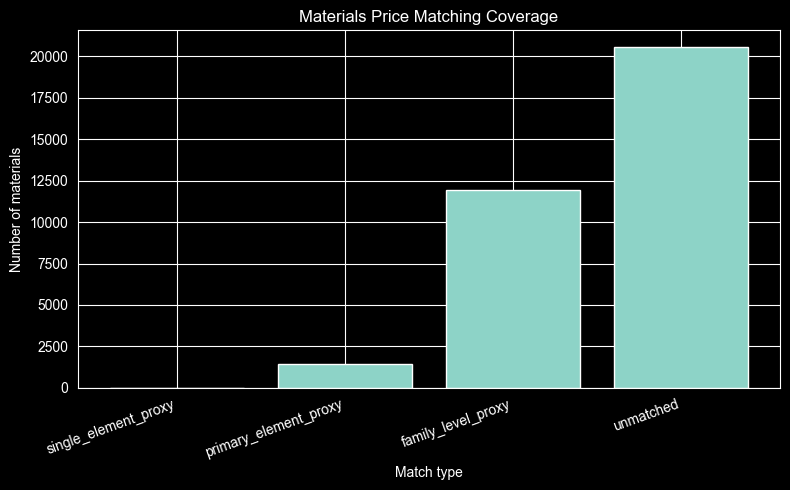

In [8]:
# Filter the data to keep the records relevant for this step.
confidence_order = ["high", "medium", "low", "none"]
plot_match_summary_df = match_summary_df.copy()
plot_match_summary_df["match_confidence"] = pd.Categorical(
    plot_match_summary_df["match_confidence"],
    categories=confidence_order,
    ordered=True,
)
# Summarise the data so patterns can be compared more easily.
plot_match_summary_df = plot_match_summary_df.sort_values(["match_confidence", "material_count"], ascending=[True, False])

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(8, 5))
plt.bar(plot_match_summary_df["match_type"], plot_match_summary_df["material_count"])
plt.title("Materials Price Matching Coverage")
plt.xlabel("Match type")
plt.ylabel("Number of materials")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Save price-matching outputs

In [9]:
# Save the processed output so later notebooks or report sections can reuse it.
cost_materials_df.to_csv(cost_materials_filtered_output, index=False)
materials_with_prices_df.to_csv(matched_materials_output, index=False)
match_summary_df.to_csv(match_summary_output, index=False)

print(f"Saved matched materials to: {matched_materials_output}")
print(f"Saved filtered material cost data to: {cost_materials_filtered_output}")
print(f"Saved match summary to: {match_summary_output}")

Saved matched materials to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\materials_with_price_matches.csv
Saved filtered material cost data to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\supporting\world_bank_material_costs_filtered.csv
Saved match summary to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_pricing\supporting\materials_price_match_summary.csv
